In [1]:
import fitness_landscape as fl
from fitness_landscape.utils import fasta_to_prot20_sequences
from fitness_landscape.core.landscape import FitnessLandscape
from fitness_landscape.transforms.eigenmode import eigenmode_decomposition
from collections import defaultdict
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import re
import pickle
import json
from tqdm import tqdm
import networkx as nx
import pandas as pd
#import statsmodels.formula.api as smf
from scipy.stats import spearmanr
from scipy.stats import norm
import matplotlib as mpl

## Heat kernel demonstration
Diagrammatic explanation of the diffusion scale and intuition behind the heat kernel in variance modelling. 

In [313]:
t_values = [0, 2, 10]

# Initialize NK landscape dummy graph
nk = fl.models.nk.create_nk_binary_landscape(N=4, K=0, seed=42)

for t_value in t_values:
    # Compute covariance for t
    covariance_result = fl.analysis.diffusion_scale.compute_ruggedness_variance_energy(nk, t=t_value)

    # Collect covariance matrix
    C = covariance_result["covariance_matrix"]
    n = C.shape[0]
    mu = np.zeros(n)
    # symmetrize to avoid tiny numerical asymmetries
    C = 0.5 * (C + C.T)
    # sample one signal
    f = np.random.multivariate_normal(mean=mu, cov=C, check_valid="warn")

    # Attach eigenvector as layer
    layer_name = f"laplacian_eigvec_{t_value}"
    nk.attach(
        name=layer_name,
        values=f,
        dtype="numeric",
    )

/tmp/ipykernel_29803/3868434726.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


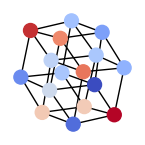

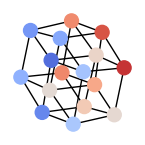

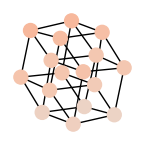

/tmp/ipykernel_29803/3868434726.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


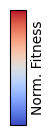

In [314]:
# Plot sampled fitness values
arrays = np.hstack([nk.fitness_layers[f'laplacian_eigvec_{t_value}'].to_scalar() for t_value in t_values])

for t_value in t_values:
    
    plt.figure(figsize=(1.25, 1.25))
    pos = nx.spring_layout(nk.graph, seed=42)
    nx.draw(nk.graph, pos=pos, with_labels=False, node_size=100, node_color=nk.fitness_layers[f'laplacian_eigvec_{t_value}'].to_scalar(), cmap="coolwarm", vmin=arrays.min(), vmax=arrays.max())
    plt.tight_layout()
    plt.savefig(f"../figures/figure_1/N4_{t_value}_graph.pdf")
    plt.show()

# Plot colourbar
fig, ax = plt.subplots(figsize=(0.2, 1.5)) 

norm = mpl.colors.Normalize(vmin=arrays.min(), vmax=arrays.max())
sm = mpl.cm.ScalarMappable(norm=norm, cmap="coolwarm")
sm.set_array([])  # required for older matplotlib versions

cbar = plt.colorbar(sm, cax=ax)
cbar.set_label("Norm. Fitness", rotation=90)

cbar.ax.tick_params(
    axis="y",
    which="both",
    length=0,
    labelleft=False)

cbar.set_ticks([])

plt.tight_layout()
plt.savefig("../figures/figure_1/N4_fitness_colorbar.pdf")
plt.show()

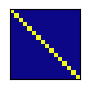

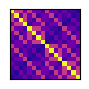

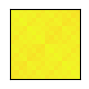

/tmp/ipykernel_59058/560013565.py:51: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


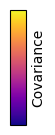

In [3]:
# Plot Covariance matrices
# Reinitialise variables (safe)

t_values = [0, 2, 10]

# Initialize NK landscape dummy graph
nk = fl.models.nk.create_nk_binary_landscape(N=4, K=0, seed=42)

# Init emtpy array for scaling
C_arrays = []


for t_value in t_values:
    # Compute covariance for t
    covariance_result = fl.analysis.diffusion_scale.compute_ruggedness_variance_energy(nk, t=t_value)

    # Collect covariance matrix
    C = covariance_result["covariance_matrix"]
    C_arrays.append(C)

vmin = min(C.min() for C in C_arrays)
vmax = max(C.max() for C in C_arrays)
for t_value, C in zip(t_values, C_arrays):
    plt.figure(figsize=(1, 1))
    plt.imshow(C, cmap="plasma", vmin=vmin, vmax=vmax)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.savefig(f"../figures/figure_1/N4_{t_value}_covariance.png", dpi=600)
    plt.show()

# Plot colourbar
fig, ax = plt.subplots(figsize=(0.2, 1.5)) 

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="plasma")
sm.set_array([])  # required for older matplotlib versions

cbar = plt.colorbar(sm, cax=ax)
cbar.set_label("Covariance", rotation=90)


cbar.ax.tick_params(
    axis="y",
    which="both",
    length=0,
    labelleft=False)

cbar.set_ticks([])

plt.tight_layout()
plt.savefig("../figures/figure_1/N4_covariance_colorbar.pdf")
plt.show()

## NK landscapes
In these systems, K is the parameter that controls ruggedness.

In [2]:
# Init dict to store replicates
replicate_dict = {}

# Number of replicates
num_replicates = 10
for replicate in range(num_replicates): 

    # Init dict to store results
    tmap_dict = {}

    # Range of N variables to consider
    n_range = list(range(4, 11))

    # Define K up to N-1 for each N
    for n_param in n_range:
        k_range = list(range(0, n_param))
        
        # Construct NK landscapes and compute diffusion map for each (N, K)
        for k_param in k_range:
            nk = fl.models.nk.create_nk_binary_landscape(N=n_param, K=k_param, seed=replicate)
            tmap_dict[(n_param, k_param)] = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(nk, t_min=1e-10, t_max=1e2, prior='uniform')

    # Store replicate results
    replicate_dict[replicate] = tmap_dict

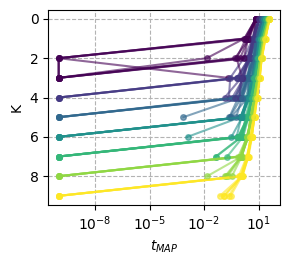

In [3]:

# replicate_dict: {rep: {(N, K): {'t_map': ... , ...}, ...}, ...}
# Restructure to: restructured[rep][N] -> list of (K, t_map)

restructured = defaultdict(lambda: defaultdict(list))
all_n_values = set()

for rep, tmap_dict in replicate_dict.items():
    for (n, k), res in tmap_dict.items():
        t = res["t_map"]  # <- new field name
        restructured[rep][n].append((k, t))
        all_n_values.add(n)

sorted_n = sorted(all_n_values)

fig, ax = plt.subplots(figsize=(3, 2.75))
cmap = plt.get_cmap("viridis")
colors = {n: cmap(i / (len(sorted_n) - 1 if len(sorted_n) > 1 else 1))
          for i, n in enumerate(sorted_n)}

for rep_data in restructured.values():
    for n_value, points in rep_data.items():
        points.sort(key=lambda x: x[0])  # sort by K
        k_vals = [k for k, _ in points]
        tmap_vals = [t for _, t in points]

        ax.plot(
            tmap_vals, k_vals,
            color=colors[n_value],
            alpha=0.6,
            marker="o",
            markersize=4,
            linestyle="-"
        )

ax.set_xlabel(r"$t_{MAP}$")
ax.set_ylabel("K")
ax.set_xscale("log")
ax.invert_yaxis()
ax.grid(True, which="both", ls="--", c="0.7")

plt.tight_layout()
plt.savefig("../figures/figure_1/tmap_vs_k.pdf")
plt.show()

## Statistics on NK landscapes
Regress tmap against N and K independently. This shows how strongly K influences tmap at constant N, and vice versa. 

In [4]:
# Convert to to long form dataframe
rows = []
for rep, rep_data in restructured.items():
    for N, points in rep_data.items():
        for K, t in points:
            rows.append({
                "replicate": rep,
                "N": N,
                "K": K,
                "t_map": t,
                "log_t_map": np.log(t)
            })

df = pd.DataFrame(rows)

In [5]:
rho, p_value = spearmanr(df["K"], df["t_map"])
print(f"Spearman correlation between K and t_map: rho={rho:.4f}, p-value={p_value:.4g}")

Spearman correlation between K and t_map: rho=-0.7612, p-value=7.484e-94


In [ ]:

# OLS on parameter K with constant terms for N.
model_K = smf.ols(
    "log_t_map ~ K + C(N)",
    data=df
).fit(cov_type="HC3")  # robust SEs

print(model_K.summary())

                            OLS Regression Results                            
Dep. Variable:              log_t_map   R-squared:                       0.447
Model:                            OLS   Adj. R-squared:                  0.439
Method:                 Least Squares   F-statistic:                     33.73
Date:                Thu, 08 Jan 2026   Prob (F-statistic):           3.28e-38
Time:                        12:01:32   Log-Likelihood:                -1250.7
No. Observations:                 490   AIC:                             2517.
Df Residuals:                     482   BIC:                             2551.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.3408      0.835     -1.606      0.1

In [85]:
# Comnpute p-value from z-score
z = -14.412
p = 2 * norm.sf(abs(z))
print(p)

4.349308815511996e-47


In [ ]:
# OLS on parameter N with constant terms for K.
model_N = smf.ols( 
    "log_t_map ~ N + C(K)",
    data=df
).fit(cov_type="HC3")  # robust SEs

print(model_N.summary())

                            OLS Regression Results                            
Dep. Variable:              log_t_map   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.437
Method:                 Least Squares   F-statistic:                     23.65
Date:                Thu, 08 Jan 2026   Prob (F-statistic):           3.17e-36
Time:                        12:19:05   Log-Likelihood:                -1249.8
No. Observations:                 490   AIC:                             2522.
Df Residuals:                     479   BIC:                             2568.
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.6028      0.699     -6.589      0.0

In [ ]:
# Compute p-value from z-score
z = 11.197
p = 2 * norm.sf(abs(z))
print(p)

4.2177544774554707e-29


## Elementary NK landscapes
In these systems, the Laplacian eigenvector index is the parameter that controls ruggedness.

In [112]:
# Init list to store results
results = []

# Range of N variables to consider
n_range = list(range(4, 11))

for _,n_param in tqdm(enumerate(n_range)):

    # Construct NK landscape with dummy K
    nk = fl.models.nk.create_nk_binary_landscape(N=n_param, K=0, seed=0)

    # Perform eigenmode decomposition 
    eigvals, eigvecs = eigenmode_decomposition(
        nk,
        matrix="laplacian",
    )
    
    # Total number of Laplacian eigenvectors (== number of nodes)
    n_eig = eigvecs.shape[1]  # should equal len(nk)

    # Only test first 25% of eigenmodes (skip k=0, )
    max_k = int(len(nk) * 0.50)

    for k in range(1, max_k + 1):
        # Normalized eigenvector index in (0, 1]
        k_norm = k / (n_eig - 1)

        # Attach the eigenvector as the "fitness" layer/signal
        layer_name = f"laplacian_eigvec_{k}"
        nk.attach(
            name=layer_name,
            values=eigvecs[:, k],
            dtype="numeric",
        )
        nk.view(layer_name)

        # Compute diffusion-scale ruggedness (optionally set t_min/t_max)
        tmap_res = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(
            nk,
            t_min=1e-10,
            t_max=1e2,
        )

        # Store everything you need for analysis
        results.append({
            "N": n_param,
            "num_nodes": len(nk),
            "eig_index": k,
            "eig_index_norm": k_norm,
            "eigval": float(eigvals[k]),
            "t_map": float(tmap_res["t_map"]),
            "t_lo": float(tmap_res["t_lower_confidence_interval"]),
            "t_hi": float(tmap_res["t_upper_confidence_interval"]),
            "logpost_map": float(tmap_res["t_logposterior_map"]),
            "var_approx": float(tmap_res["variance_approximate"]),
            "layer": layer_name,
        })

# Convert to DataFrame for convenience
df_eig = pd.DataFrame(results)

7it [05:18, 45.54s/it]


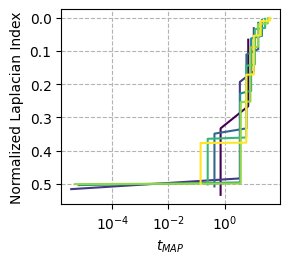

In [118]:
df = df_eig.copy()

# Collect N values and color-map them
sorted_n = sorted(df["N"].unique())
fig, ax = plt.subplots(figsize=(3, 2.75))
cmap = plt.get_cmap("viridis")
colors = {n: cmap(i / (len(sorted_n) - 1 if len(sorted_n) > 1 else 1))
          for i, n in enumerate(sorted_n)}

# Plot one line per N
for n in sorted_n:
    sub = df[df["N"] == n].sort_values("eig_index_norm")
    ax.plot(
        sub["t_map"].values,
        sub["eig_index_norm"].values,
        color=colors[n],
        alpha=1.0,
        markersize=0,
        linestyle="-",
    )

ax.set_xlabel(r"$t_{MAP}$")
ax.set_ylabel("Normalized Laplacian Index")
ax.set_xscale("log")
ax.invert_yaxis()
ax.grid(True, which="both", ls="--", c="0.7")

plt.tight_layout()
plt.savefig("../figures/figure_1/tmap_vs_norm_laplacian_idx.pdf")
plt.show()

Spectral energy distribution on additive NK landscapes. As N increases, the contribution from high frequency eigenmodes decreases thus the relationship between N and tMAP. 

In [31]:
# Init list to store results
gft_results = {}

# Range of N variables to consider
n_range = list(range(4, 11))

for _,n_param in tqdm(enumerate(n_range)):

    # Construct NK landscape with dummy K
    nk = fl.models.nk.create_nk_binary_landscape(N=n_param, K=0, seed=0)

    # Perform Graph Fourier Transform on K signal
    _, _, coefficients = fl.transforms.graph_fourier.graph_fourier_transform(nk)

    # Store everything you need for analysis
    gft_results[n_param] = coefficients


7it [00:01,  4.78it/s]


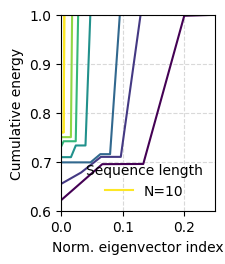

In [ ]:
xmax = 0.25

fig, ax = plt.subplots(figsize=(2.35, 2.75))

cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(n_range)))  # evenly spaced colours

for color, n_param in zip(colors, n_range):
    c = np.abs(gft_results[n_param]).astype(float)
    E = c / c.sum()
    x = np.arange(len(E)) / (len(E) - 1)
    cdf = np.cumsum(E)

    ax.plot(x, cdf, lw=1.5, color=color)

ax.set_ylim(0.6, 1)
ax.set_xlim(0, xmax)
ax.grid(True, ls="--", c="0.85")
ax.set_ylabel("Cumulative energy")
ax.set_xlabel("Norm. eigenvector index")


plt.tight_layout()
plt.savefig("../figures/figure_1/K0_GFT_cdf.pdf")
plt.show()

## Statistics on Elementary landscapes
Regress tmap against N, correcting for the normalised Laplacian index.

In [123]:
# OLS on parameter N with constant terms for K.
df['log_t_map'] = np.log(df['t_map'])
model_j = smf.ols( 
    "log_t_map ~ N + eig_index_norm",
    data=df
).fit(cov_type="HC3")  # robust SEs

print(model_j.summary())

                            OLS Regression Results                            
Dep. Variable:              log_t_map   R-squared:                       0.560
Model:                            OLS   Adj. R-squared:                  0.559
Method:                 Least Squares   F-statistic:                     421.2
Date:                Thu, 08 Jan 2026   Prob (F-statistic):          7.38e-134
Time:                        13:32:22   Log-Likelihood:                -1561.9
No. Observations:                1016   AIC:                             3130.
Df Residuals:                    1013   BIC:                             3145.
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          3.9145      0.333     11.

## Sparse Molecular Evolutionary simulation landscapes

In [6]:

indir = Path("../alisim_results")
pattern = "replicate_*.fa"
eig_max = 32
out_pkl = Path("../alisim_results/tmap_by_rep_and_eig.pkl")
out_json = Path("../alisim_results/tmap_by_rep_and_eig.json")

def _jsonable(obj):
    import numpy as _np
    if isinstance(obj, (_np.floating,)): return float(obj)
    if isinstance(obj, (_np.integer,)): return int(obj)
    if isinstance(obj, (_np.ndarray,)): return obj.tolist()
    if isinstance(obj, dict): return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [_jsonable(x) for x in obj]
    return obj

files = sorted(indir.glob(pattern))
files = [p for p in files if ".unaligned." not in p.name]
if not files:
    raise RuntimeError(f"No aligned files found in {indir} matching {pattern}")

rep_re = re.compile(r"replicate_(\d+)\.fa$")

count = 0
results = {}

for i, fasta_path in tqdm(enumerate(files)):
    if count == 100:
        break
    m = rep_re.search(fasta_path.name)
    rep_id = m.group(1) if m else fasta_path.stem.replace("replicate_", "")

    sequences = fasta_to_prot20_sequences(fasta_path)
    knn_k = max(int(np.sqrt(len(sequences))), 2)

    landscape = FitnessLandscape.build(
        sequences,
        graph="knn",
        k=knn_k,
        backend="auto",
    )

    # Check if there is more than a single connected component and skip if so
    G = landscape.graph  # nx.Graph
    if not nx.is_connected(G):
        continue

    # Compute eigenpairs once (0..eig_max)
    eigvals, eigvecs = eigenmode_decomposition(
        landscape,
        matrix="laplacian",
        k=eig_max + 1,
    )

    rep_out = {
        "file": str(fasta_path),
        "n_sequences": len(sequences),
        "knn_k": knn_k,
        "eig_max": eig_max,
        "by_eig_k": {},
    }

    for eig_k in range(1, eig_max + 1):  # 1..64 (skip 0)
        layer_name = f"laplacian_eigvec_{eig_k}"
        landscape.attach(name=layer_name, values=eigvecs[:, eig_k], dtype="numeric")
        landscape.view(layer_name)

        tmap_res = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(landscape, t_min=1e-10, t_max=1e2, prior="uniform")

        rep_out["by_eig_k"][eig_k] = {
            "eig_k": eig_k,
            "eigval": eigvals[eig_k],
            "tmap": tmap_res,
        }

    results[rep_id] = rep_out
    count += 1

100it [02:32,  1.53s/it]


In [ ]:
# # Save results dictionary 
# with open(out_pkl, "wb") as f:
#     pickle.dump(results, f)

# with open(out_json, "w") as f:
#     json.dump(_jsonable(results), f, indent=2)

In [7]:
# pkl_path = Path("../alisim_results/tmap_by_rep_and_eig.pkl")

# with open(pkl_path, "rb") as f:
#     results = pickle.load(f)


def is_reliable_tmap_fit(tmap_result, min_lower=1e-10, max_ci_orders=2):
    t_map = float(tmap_result["t_map"])
    t_lo = float(tmap_result["t_lower_confidence_interval"])
    t_hi = float(tmap_result["t_upper_confidence_interval"])

    if not np.isfinite([t_map, t_lo, t_hi]).all():
        return False
    if t_lo <= min_lower or t_hi <= t_lo:
        return False
    if not (t_lo <= t_map <= t_hi):
        return False
    if np.log10(t_hi) - np.log10(t_lo) > max_ci_orders:
        return False

    return True


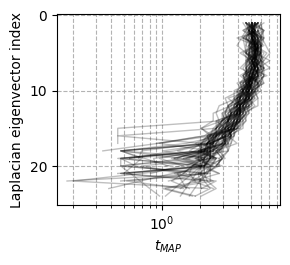

In [8]:
# Collect reliable t_map values per eigenmode index and replicate
max_eig = 24
cmap = plt.get_cmap("viridis")
replicate_color = cmap(0.0)

fig, ax = plt.subplots(figsize=(3, 2.75))

for rep_data in results.values():
    points = []

    for eig_k, d in sorted(rep_data["by_eig_k"].items()):
        if eig_k > max_eig:
            continue

        tmap_result = d["tmap"]
        if not is_reliable_tmap_fit(tmap_result):
            continue

        points.append((eig_k, float(tmap_result["t_map"])))

    if not points:
        continue

    eig_indices = [eig_k for eig_k, _ in points]
    tmap_values = [t_map for _, t_map in points]

    ax.plot(
        tmap_values,
        eig_indices,
        color='black',#replicate_color,
        alpha=0.25,
        marker="o",
        markersize=0,
        linestyle="-",
        linewidth=1,
    )

ax.set_xlabel(r"$t_{MAP}$")
ax.set_ylabel("Laplacian eigenvector index")
ax.invert_yaxis()

ax.set_yticks(range(0, max_eig + 1, 10))
ax.set_yticklabels([str(k) for k in range(0, max_eig + 1, 10)])
ax.grid(True, which="both", ls="--", c="0.7")
ax.set_xscale("log")
plt.tight_layout()
plt.savefig("../figures/figure_1/tmap_vs_laplacian_eigenvector_index.pdf")
plt.show()


## Statistics on Sparse landscapes

In [9]:
rows = []

for rep_id, rep_out in results.items():
    n = int(rep_out["n_sequences"])
    eig_max = int(rep_out.get("eig_max", 0))
    knn_k = int(rep_out["knn_k"])

    by_eig = rep_out["by_eig_k"]

    for eig_k, entry in by_eig.items():
        tmap = entry["tmap"]

        t_map = float(tmap["t_map"])
        t_lo  = float(tmap["t_lower_confidence_interval"])
        t_hi  = float(tmap["t_upper_confidence_interval"])

        eig_index_norm = eig_k / eig_max if eig_max > 0 else np.nan

        rows.append({
            "rep": rep_id,
            "file": rep_out["file"],
            "N": n,                 # NOTE: here N = n_sequences (rename if you want)
            "knn_k": knn_k,
            "eig_max": eig_max,
            "eig_k": int(eig_k),
            "eig_index_norm": float(eig_index_norm),
            "eigval": float(entry["eigval"]),
            "t_map": t_map,
            "t_lo": t_lo,
            "t_hi": t_hi,
            "logpost_map": float(tmap["t_logposterior_map"]),
            "var_approx": float(tmap["variance_approximate"]),
        })

df = pd.DataFrame(rows)

# basic cleaning for safety
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["t_map", "eig_index_norm", "N"])
df = df[df["t_map"] > 0].copy()

df["log_t_map"] = np.log(df["t_map"])

In [10]:
rho, p_value = spearmanr(df["eig_k"], df["t_map"])
print(f"Spearman correlation between Laplacian eigenvector index and t_map: rho={rho:.4f}, p-value={p_value:.4g}")

Spearman correlation between Laplacian eigenvector index and t_map: rho=-0.9376, p-value=0


In [11]:
df

,rep,file,N,knn_k,eig_max,eig_k,eig_index_norm,eigval,t_map,t_lo,t_hi,logpost_map,var_approx,log_t_map
0,001,../alisim_results/replicate_001.fa,128,11,64,1,0.015625,61.507640,5.347707,5.083435e+00,5.611979,274.357233,0.018180,1.676668
1,001,../alisim_results/replicate_001.fa,128,11,64,2,0.031250,124.366923,5.377097,5.115714e+00,5.638479,276.481269,0.017784,1.682149
2,001,../alisim_results/replicate_001.fa,128,11,64,3,0.046875,540.740497,5.516681,5.251143e+00,5.782219,279.017246,0.018354,1.707776
3,001,../alisim_results/replicate_001.fa,128,11,64,4,0.062500,617.063185,5.353384,5.092573e+00,5.614195,273.779941,0.017707,1.677729
4,001,../alisim_results/replicate_001.fa,128,11,64,5,0.078125,1216.066139,6.150464,5.890831e+00,6.410097,304.956881,0.017547,1.816528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4283,099,../alisim_results/replicate_099.fa,128,11,64,60,0.937500,4045.725571,0.000005,1.000000e-10,2.532495,128.903813,1.669489,-12.287134
4284,099,../alisim_results/replicate_099.fa,128,11,64,61,0.953125,4055.461060,0.000005,1.000000e-10,2.641479,128.903817,1.816271,-12.226380
4285,099,../alisim_results/replicate_099.fa,128,11,64,62,0.968750,4065.840115,0.000004,1.000000e-10,2.222394,128.903835,1.285667,-12.554203
4286,099,../alisim_results/replicate_099.fa,128,11,64,63,0.984375,4071.579201,0.000005,1.000000e-10,2.509632,128.903820,1.639481,-12.166227


In [16]:
model_j = smf.ols(
    "t_map ~ eig_k",
    data=df
).fit(cov_type="HC3")

print(model_j.summary())

                            OLS Regression Results                            
Dep. Variable:                  t_map   R-squared:                       0.630
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     6697.
Date:                Mon, 12 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:26:53   Log-Likelihood:                -7140.6
No. Observations:                4288   AIC:                         1.429e+04
Df Residuals:                    4286   BIC:                         1.430e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.2469      0.048     89.320      0.0

In [17]:
# Compute p-value from z-score
from scipy.stats import norm

z = -81.838

log10_p_two_sided = np.log10(2) + norm.logsf(abs(z)) / np.log(10)
log10_p_two_sided

np.float64(-1456.3456588396382)

Landscape visualisation at different Laplacian eigenmode indices

In [8]:
pattern = "replicate_*.fa"
indir = Path("../alisim_results")
files = sorted(indir.glob(pattern))
files = [p for p in files if ".unaligned." not in p.name]
if not files:
    raise RuntimeError(f"No aligned files found in {indir} matching {pattern}")

rep_re = re.compile(r"replicate_(\d+)\.fa$")

m = rep_re.search(files[0].name)
rep_id = m.group(1) if m else files[0].stem.replace("replicate_", "")

sequences = fasta_to_prot20_sequences(files[0])
knn_k = max(int(np.sqrt(len(sequences))), 2)

landscape = FitnessLandscape.build(
    sequences,
    graph="knn",
    k=knn_k,
    backend="auto",
)

# Compute eigenpairs once (0..eig_max)

eig_max = 19

eigvals, eigvecs = eigenmode_decomposition(
    landscape,
    matrix="laplacian",
    k=eig_max + 1,
)

for eig_k in range(1, eig_max + 1): 
    layer_name = f"laplacian_eigvec_{eig_k}"
    landscape.attach(name=layer_name, values=eigvecs[:, eig_k], dtype="numeric")
    landscape.view(layer_name)

/tmp/ipykernel_72537/1759343199.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


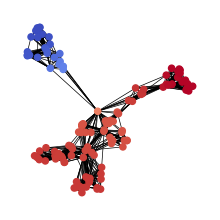

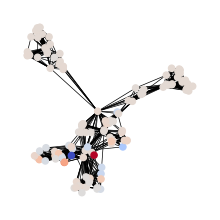

In [30]:
layers = [item for item in landscape.fitness_layers.keys()]
indices = [0,-1]
for index in indices:
    f = landscape.fitness_layers[layers[index]].to_scalar()
    G = landscape.graph  # nx.Graph
    pos = nx.spring_layout(G, seed=0)
    plt.figure(figsize=(2, 2))
    nx.draw(G, pos=pos, with_labels=False, node_size=20, width=0.5, node_color=f, cmap="coolwarm")
    plt.tight_layout()
    plt.savefig("../figures/figure_1/alisim_rep1_eigvec_{}.pdf".format(layers[index].split("_")[-1]))
    plt.show()

